### Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from PIL import Image
import random, os
from sklearn.preprocessing import StandardScaler

### Load Data

In [2]:
IN = Path.cwd() / "data_frames"

train_df     = pd.read_parquet(IN / "train_df.parquet")
val_df       = pd.read_parquet(IN / "val_df.parquet")
train_df_nl  = pd.read_parquet(IN / "train_df_nl.parquet")
val_df_nl    = pd.read_parquet(IN / "val_df_nl.parquet")

# Arrays + feature names
arr = np.load(IN / "meta_arrays_v1.npz", allow_pickle=True)
Xtr_meta, Xva_meta = arr["Xtr"], arr["Xva"]
ytr, yva = arr["ytr"], arr["yva"]
kept_feature_cols = arr["feat_cols"].tolist()

### Visualize label frequency

Text(0, 0.5, 'frequency')

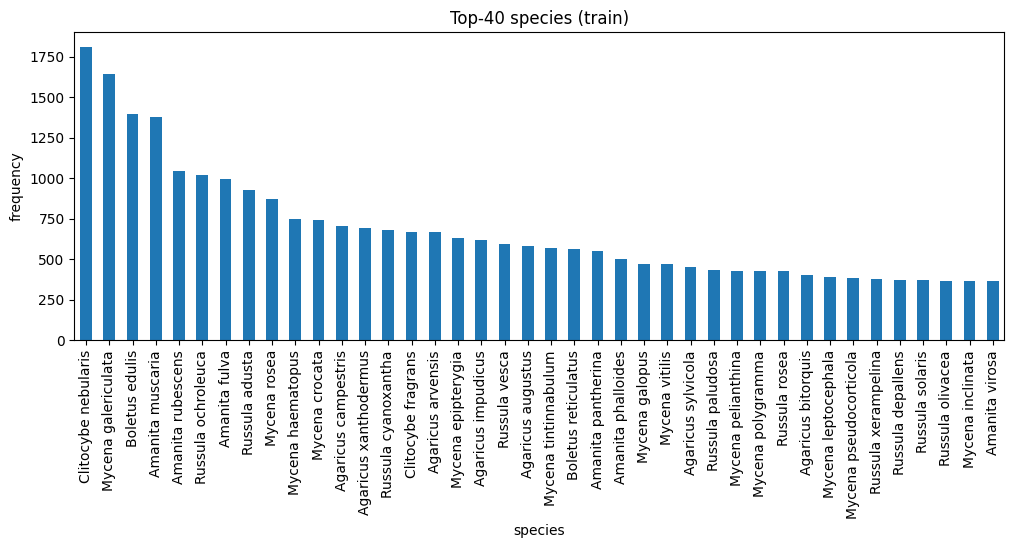

In [3]:
LABEL = "species" if "species" in train_df.columns else "category_id"

vc = train_df[LABEL].value_counts()
ax = vc.head(40).plot(kind="bar", figsize=(12,4)); ax.set_title("Top-40 species (train)"); ax.set_ylabel("frequency")



Text(0, 0.5, 'frequency')

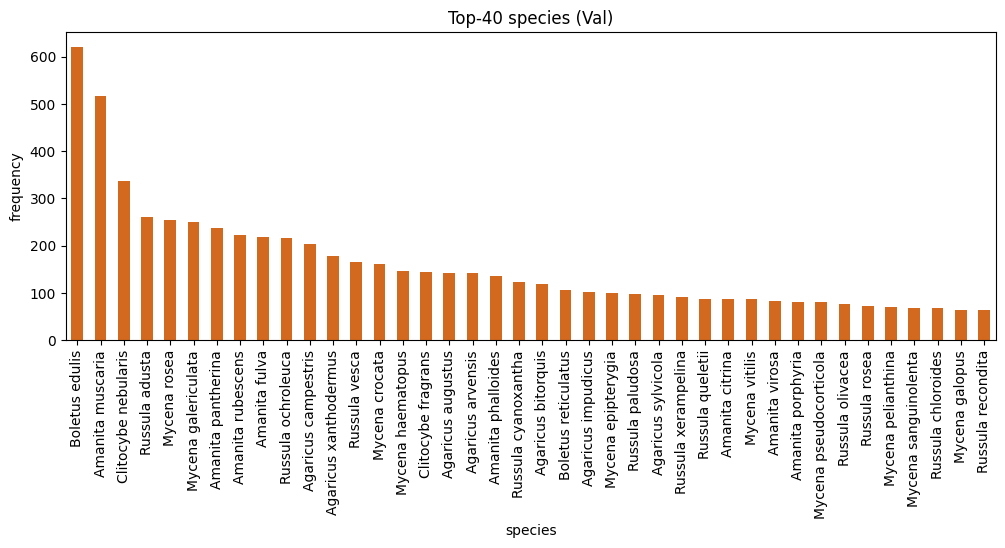

In [32]:
LABEL = "species" if "species" in val_df.columns else "category_id"

vc = val_df[LABEL].value_counts()
ax = vc.head(40).plot(kind="bar", figsize=(12,4), color="chocolate"); ax.set_title("Top-40 species (Val)"); ax.set_ylabel("frequency")



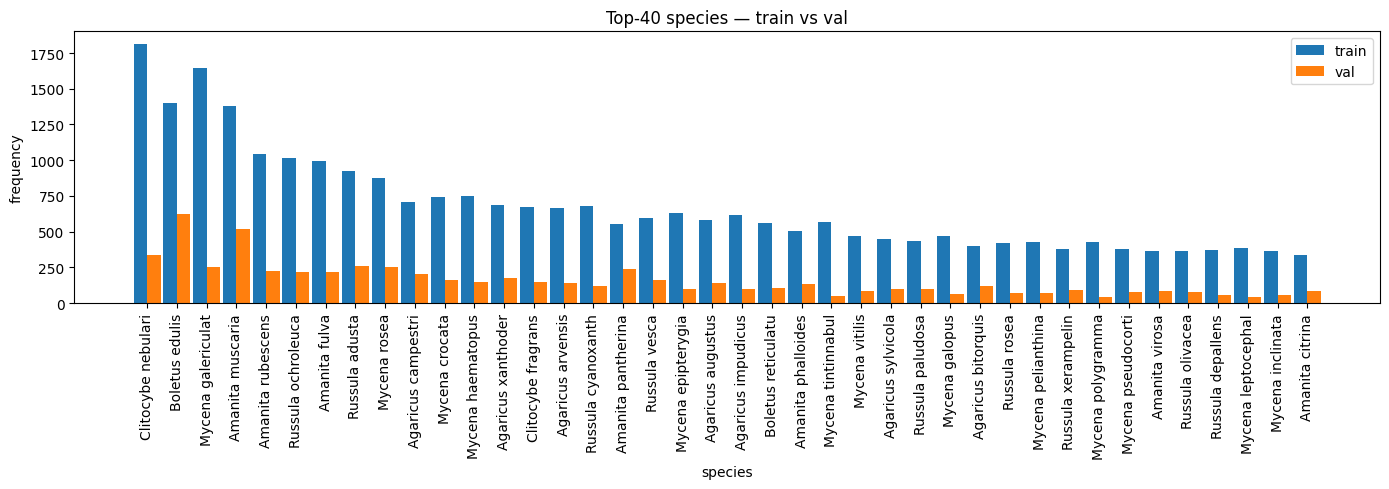

In [4]:
LABEL = "species" if "species" in train_df.columns else "category_id"
TOPK = 40

# Top-K species overall (train+val), then keep that order by train freq
overall_top = (pd.concat([train_df[LABEL], val_df[LABEL]])
               .value_counts().head(TOPK).index)

train_counts = train_df[LABEL].value_counts().reindex(overall_top, fill_value=0)
val_counts   = val_df[LABEL].value_counts().reindex(overall_top, fill_value=0)

# (Optional) show percentages instead of raw counts
# train_counts = (train_counts / len(train_df) * 100)
# val_counts   = (val_counts   / len(val_df)   * 100)

x = np.arange(len(overall_top))
w = 0.45

plt.figure(figsize=(14, 5))
plt.bar(x - w/2, train_counts.values, width=w, label="train")
plt.bar(x + w/2, val_counts.values,   width=w, label="val")
plt.xticks(x, [str(s)[:18] for s in overall_top], rotation=90)
plt.ylabel("frequency")  # or "% of split" if you enabled percentages
plt.xlabel("species")
plt.title(f"Top-{TOPK} {LABEL} — train vs val")
plt.legend()
plt.tight_layout()
plt.show()


_________
### Image visualization

Sample Images from the Training set


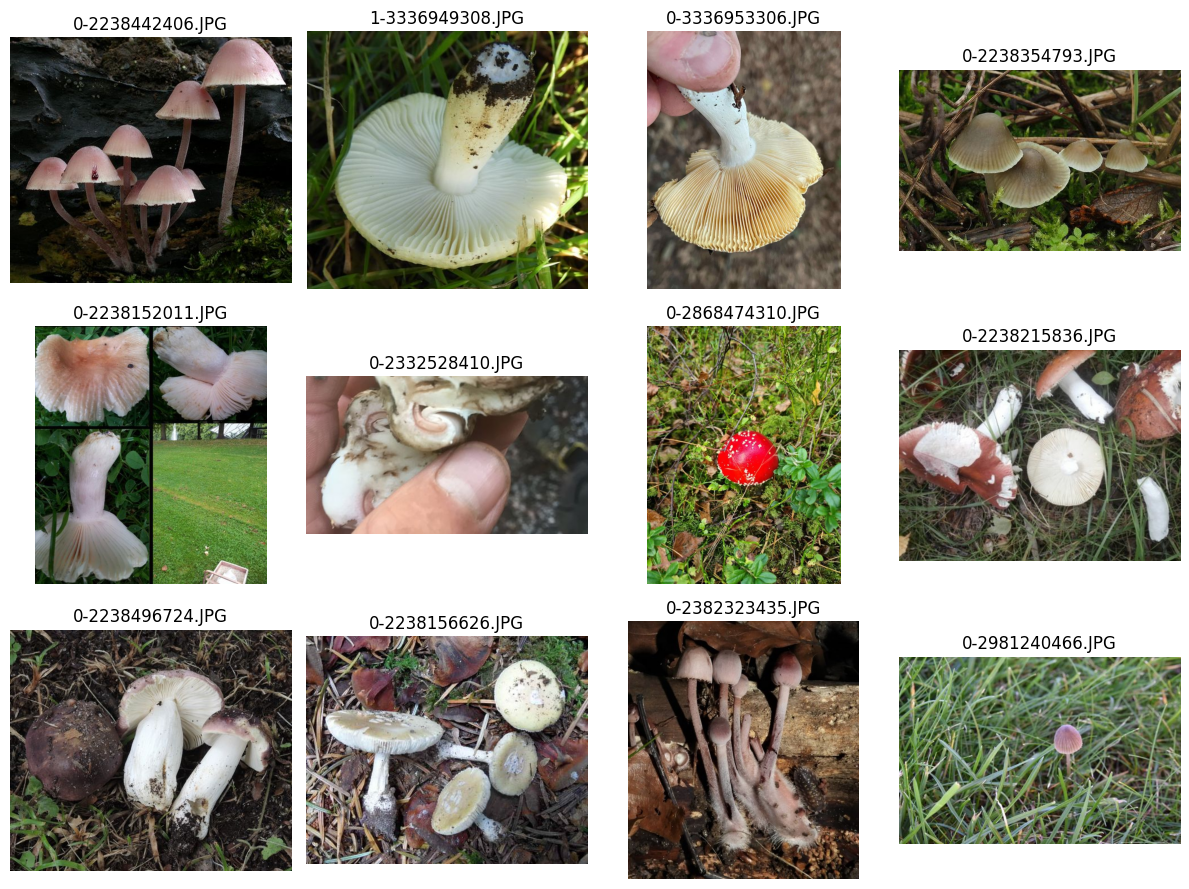

In [33]:


def show_images(df, n=12):
    paths = df["image_path"].sample(n, random_state=0).tolist()
    cols, rows = 4, int(np.ceil(n/4))
    plt.figure(figsize=(12, 3*rows))
    for i,p in enumerate(paths, 1):
        plt.subplot(rows, cols, i); 
        try:
            plt.imshow(Image.open(p)); plt.axis("off"); plt.title(os.path.basename(p)[:20])
        except Exception as e:
            plt.text(0.5,0.5,"Missing/Corrupt", ha="center"); plt.axis("off")
    plt.tight_layout(); plt.show()
print("Sample Images from the Training set")
show_images(train_df, n=12)


In [23]:

def plot_species_grid(df, df_name, label_col="species", path_col="image_path",
                      species_list=None, top_k=5, n_per=6, random_state=0):
    """
    Draws a grid: one row per species, 6 images per row.
    If species_list is None, uses top_k most frequent species in df.
    """
    rng = np.random.default_rng(random_state)

    # pick which species to show
    if species_list is None:
        species_list = df[label_col].value_counts().head(top_k).index.tolist()

    rows = len(species_list)
    cols = n_per

    # size tuning: 6 images per row, keep each thumb ~2.2 inches wide
    fig, axs = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
    if rows == 1:
        axs = np.array([axs])  # normalize shape (rows, cols)

    for r, sp in enumerate(species_list):
        # sample up to n_per images for this species
        sub = df[df[label_col] == sp]
        idx = rng.choice(len(sub), size=min(n_per, len(sub)), replace=False)
        paths = sub.iloc[idx][path_col].tolist()

        for c in range(cols):
            ax = axs[r, c]
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_frame_on(False)

            if c < len(paths):
                p = paths[c]
                try:
                    img = Image.open(p).convert("RGB")
                    ax.imshow(img)
                except Exception:
                    ax.text(0.5, 0.5, "missing/corrupt", ha="center", va="center")
            else:
                # not enough images—leave blank
                ax.text(0.5, 0.5, "", ha="center", va="center")

        # put the species name as a per-row label on the leftmost subplot
        axs[r, 0].set_ylabel(sp, rotation=0, ha="right", va="center",
                             labelpad=40, fontsize=9)

    plt.subplots_adjust(left=0.18, wspace=0.02, hspace=0.12)
    plt.suptitle(f"{rows} species × {cols} images each for {df_name}", y=0.995)
    plt.tight_layout()
    plt.show()


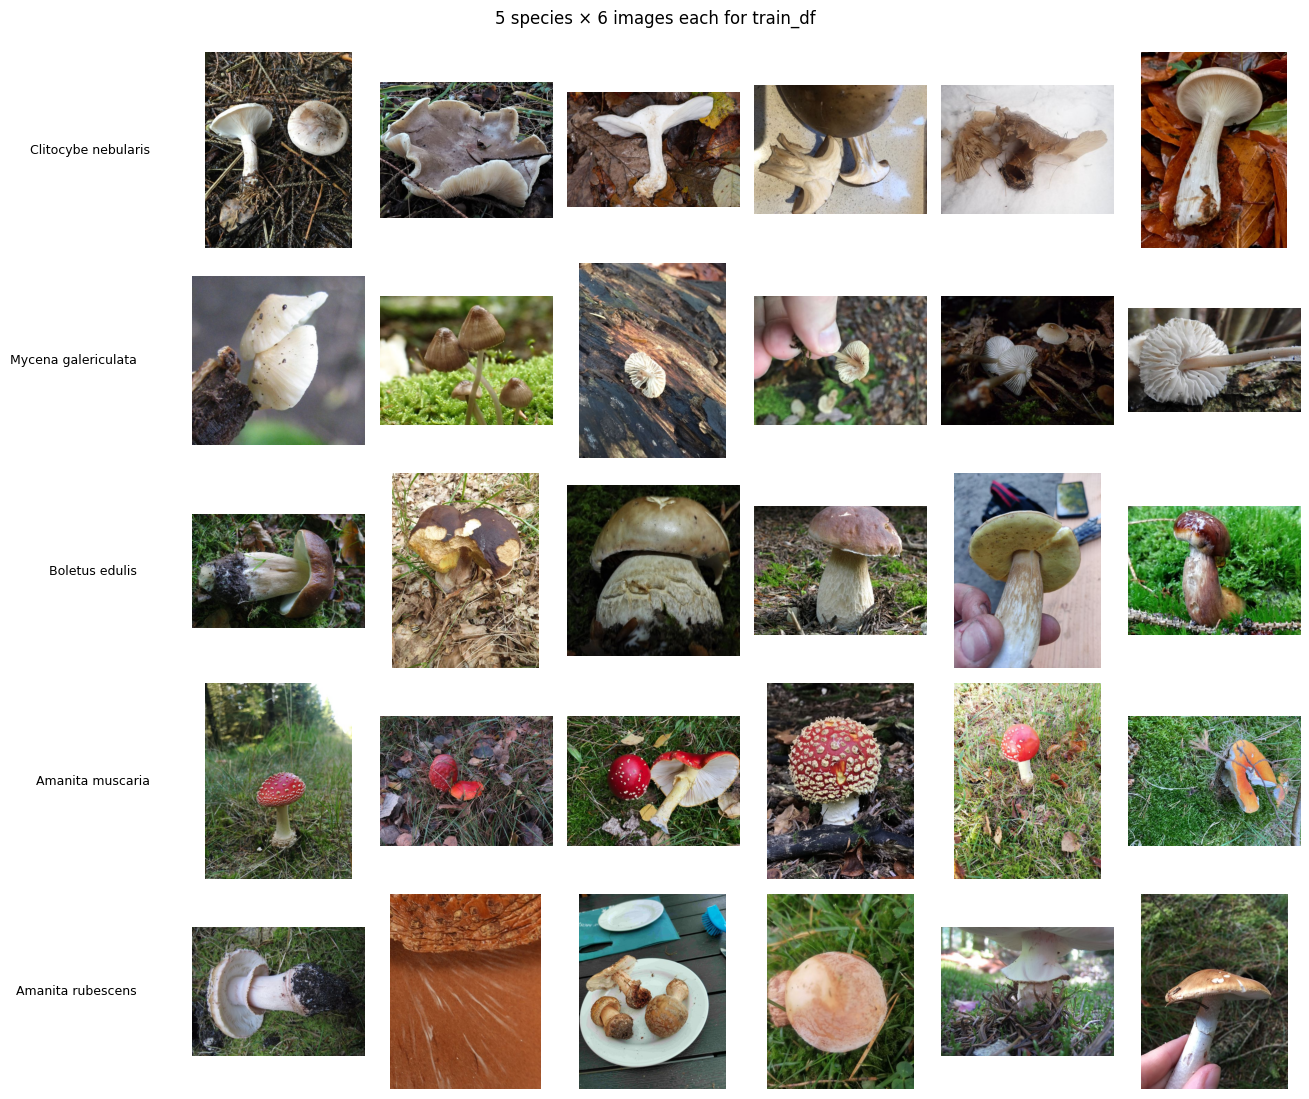

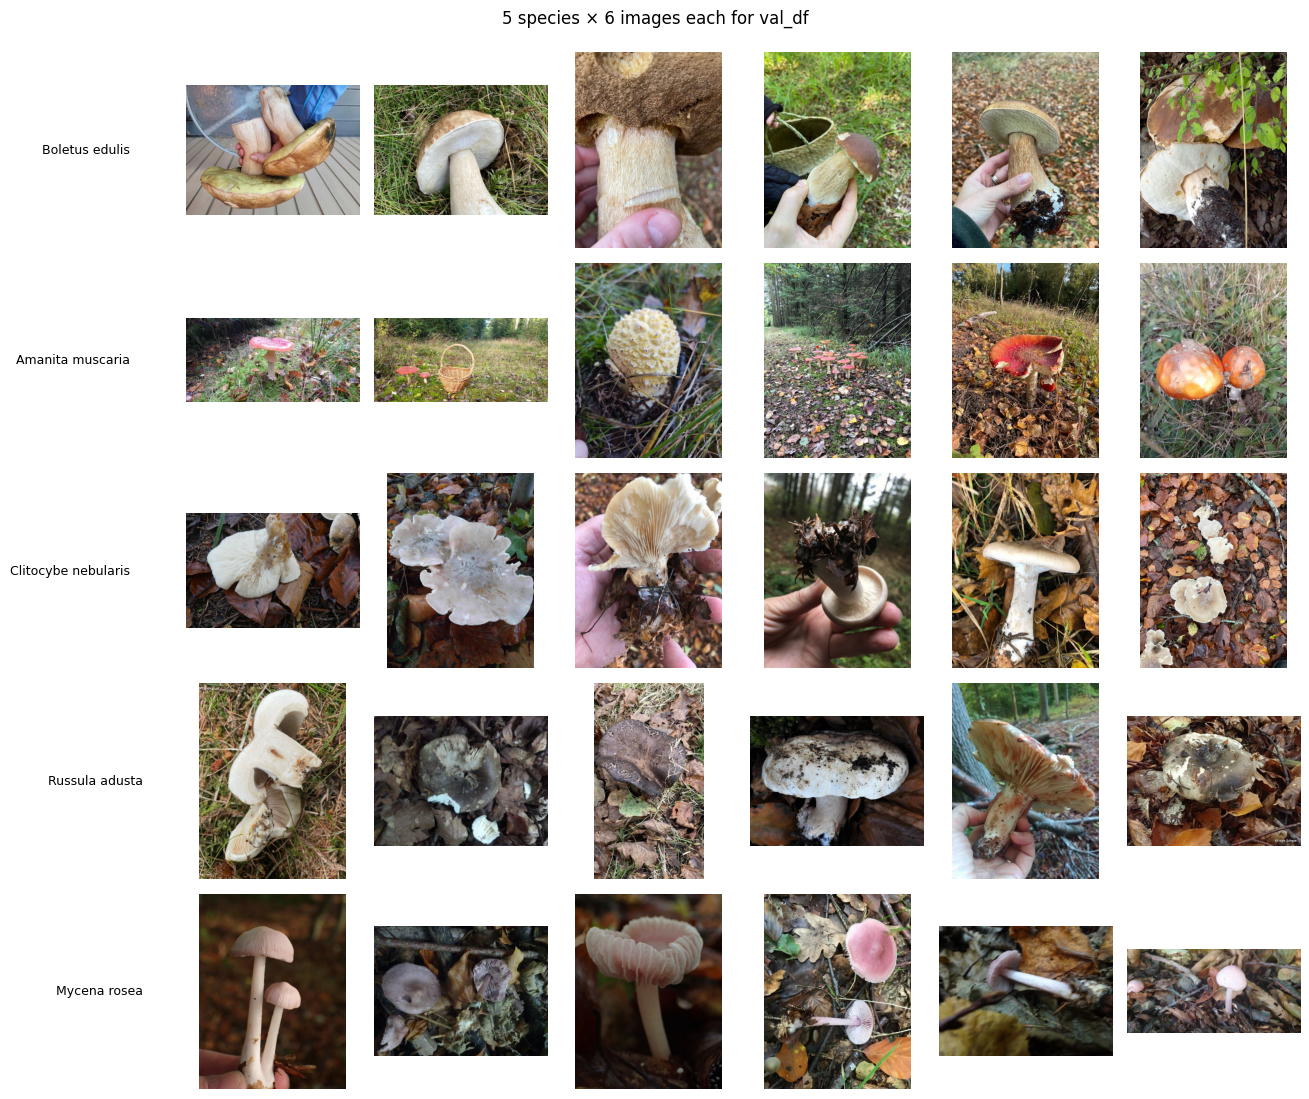

In [37]:
# Top 5 species, 6 images each (train_df)
plot_species_grid(train_df, "train_df" ,label_col="species", path_col="image_path",
                  top_k=5, n_per=6, random_state=42)

# Top 5 species, 6 images each (val_df)
plot_species_grid(val_df, "val_df",label_col="species", path_col="image_path",
                  top_k=5, n_per=6, random_state=42)


### Metadata Exploration


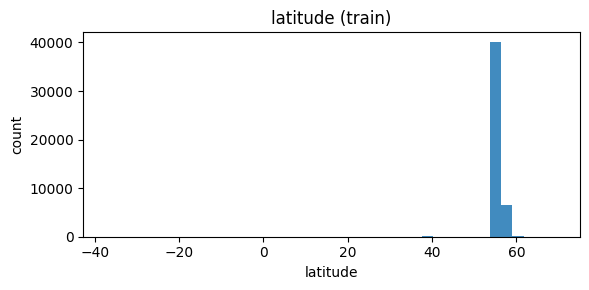

latitude: n=46841, mean=55.77, std=1.04, skew=-23.06


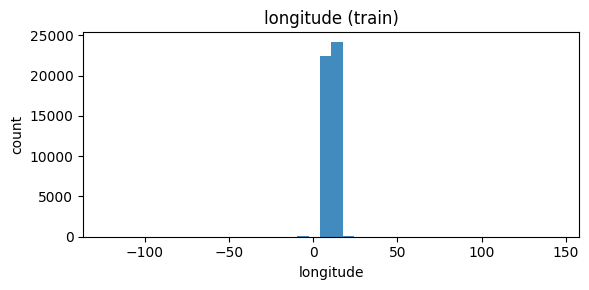

longitude: n=46841, mean=11.05, std=2.37, skew=-14.52


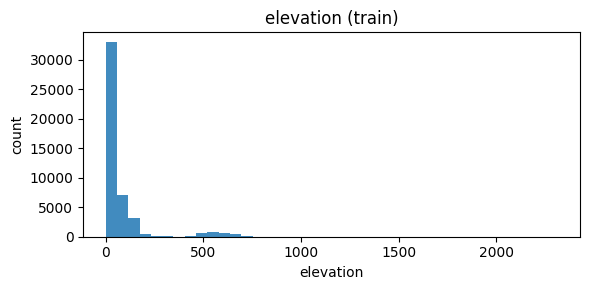

elevation: n=46799, mean=67.64, std=139.22, skew=3.34


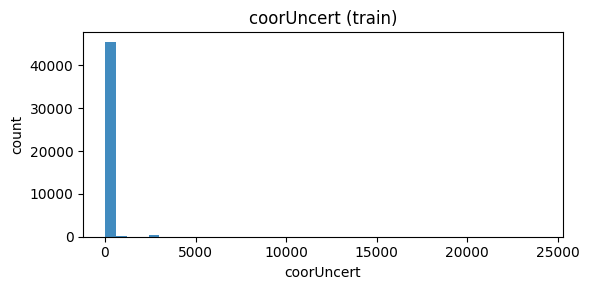

coorUncert: n=46123, mean=71.64, std=329.38, skew=19.10


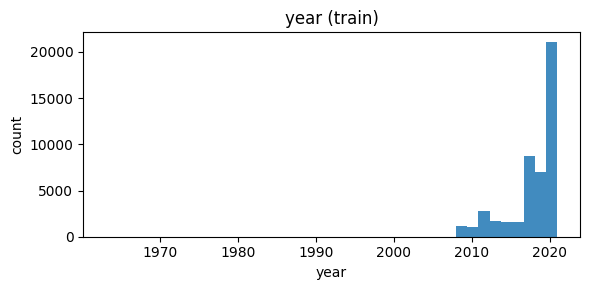

year: n=46842, mean=2017.98, std=3.48, skew=-1.93


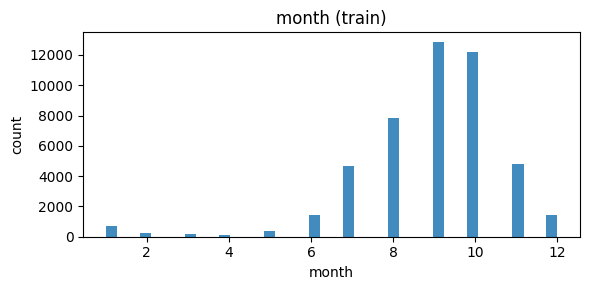

month: n=46842, mean=8.87, std=1.82, skew=-1.62


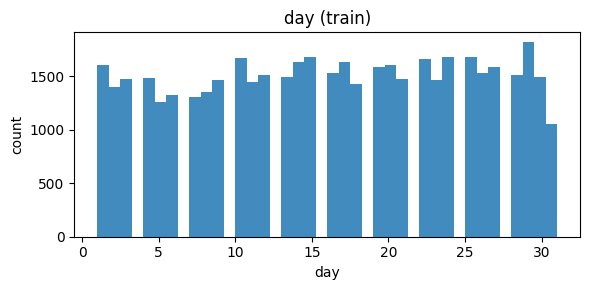

day: n=46842, mean=16.21, std=8.82, skew=-0.06


/var/folders/_b/p210wqls6zd1qw_5y0_7w5_m0000gn/T/ipykernel_42481/4121699387.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.title(f"{c}: top-{TOP} (train)"); plt.ylabel("count"); plt.tight_layout(); plt.show()


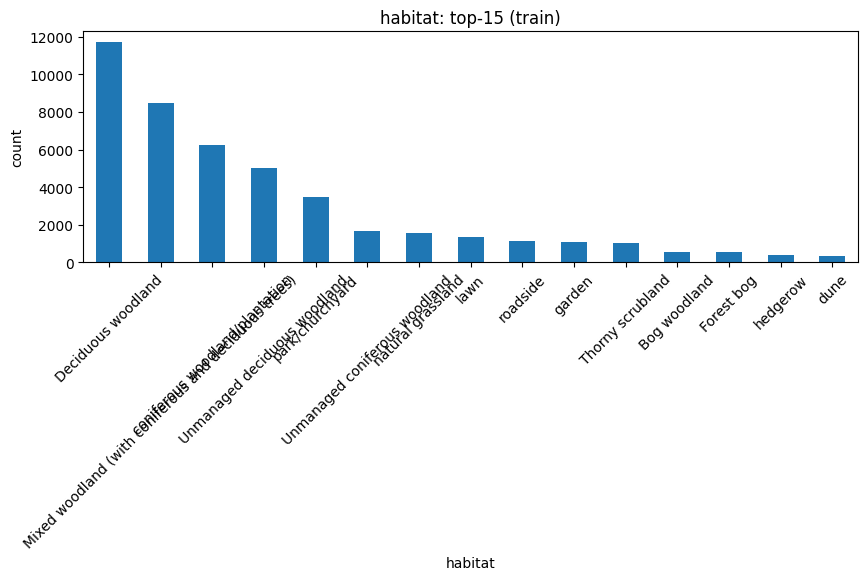

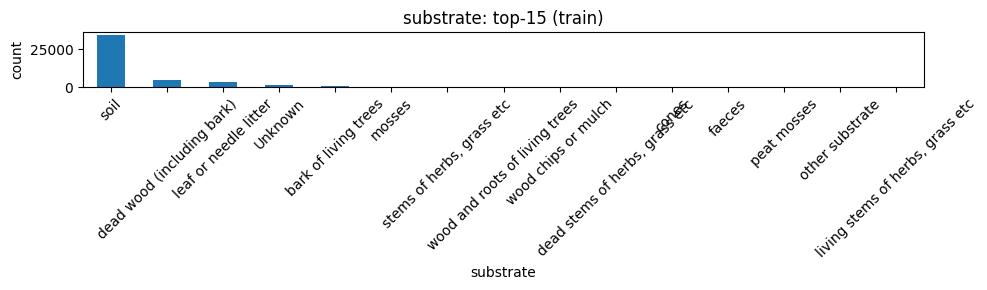

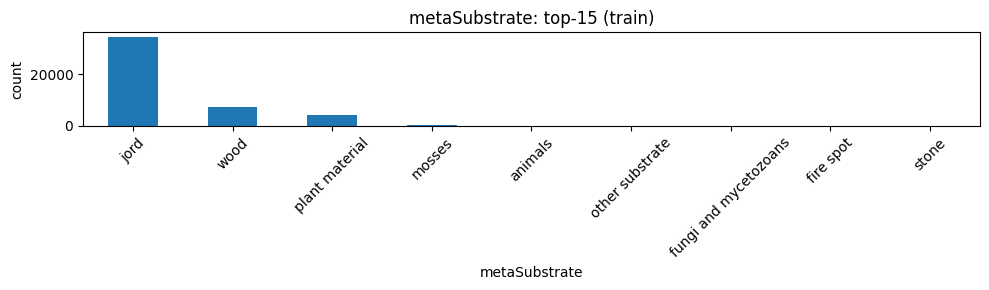

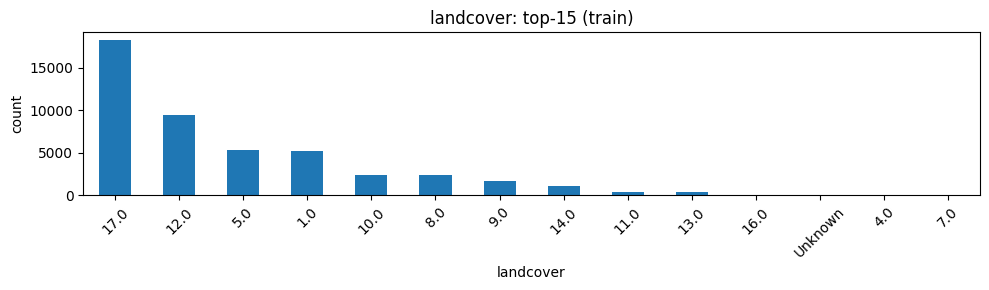

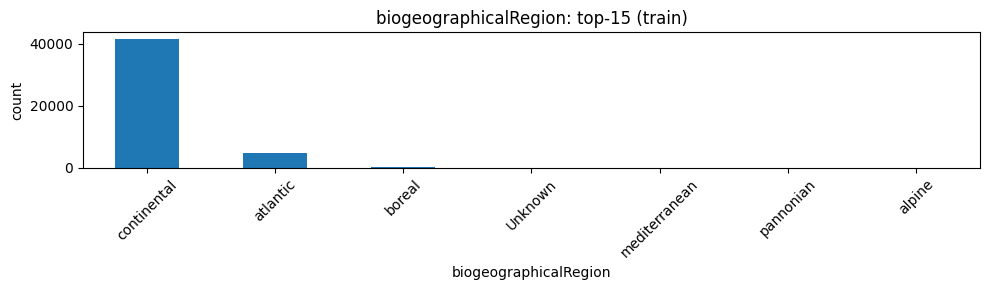

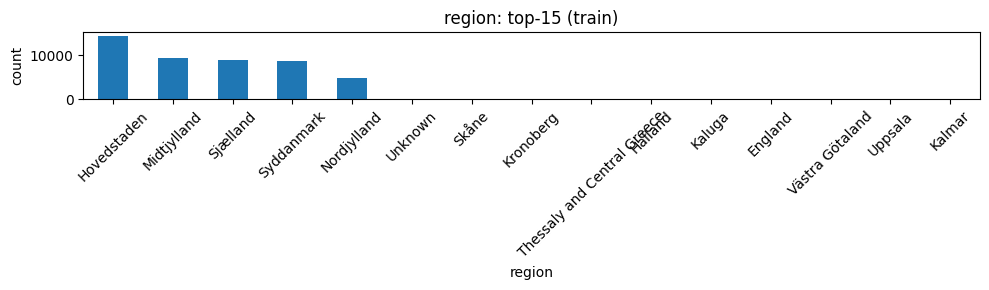

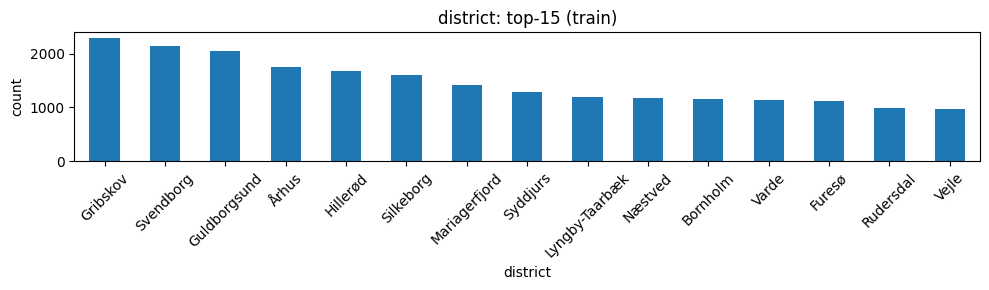

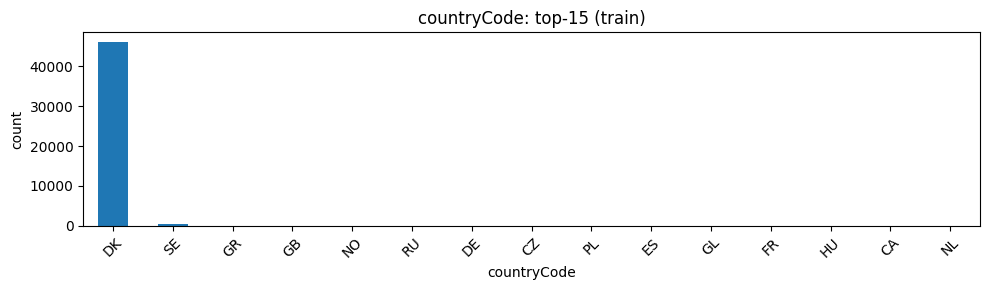

In [38]:
# Pick specific columns
LABEL = "species" if "species" in train_df.columns else "category_id"

NUM_COLS = [c for c in ["latitude","longitude","elevation","coorUncert","year","month","day"]
            if c in train_df.columns]

CAT_COLS = [c for c in ["habitat","substrate","metaSubstrate","landcover",
                        "biogeographicalRegion","region","district","countryCode"]
            if c in train_df.columns]

# Checking Distributions
for c in NUM_COLS:
    plt.figure(figsize=(6,3))
    train_df[c].dropna().plot(kind="hist", bins=40, alpha=0.85)
    plt.title(f"{c} (train)"); plt.xlabel(c); plt.ylabel("count"); plt.tight_layout(); plt.show()

    # quick skew (Fisher-Pearson)
    s = train_df[c].dropna()
    print(f"{c}: n={len(s)}, mean={s.mean():.2f}, std={s.std():.2f}, skew={s.skew():.2f}")

# Checking categorical frequencies 
TOP = 15
for c in CAT_COLS:
    plt.figure(figsize=(10,3))
    train_df[c].fillna("Unknown").value_counts().head(TOP).plot(kind="bar", rot=45)
    plt.title(f"{c}: top-{TOP} (train)"); plt.ylabel("count"); plt.tight_layout(); plt.show()


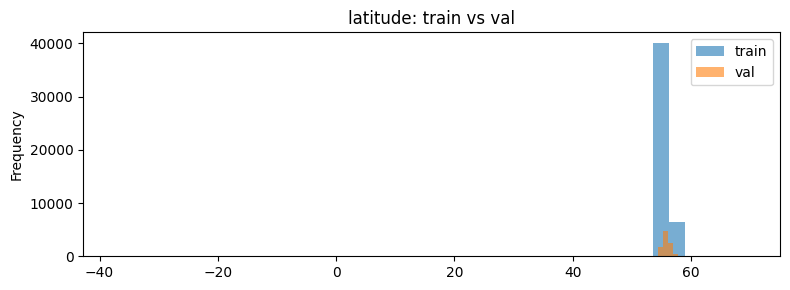

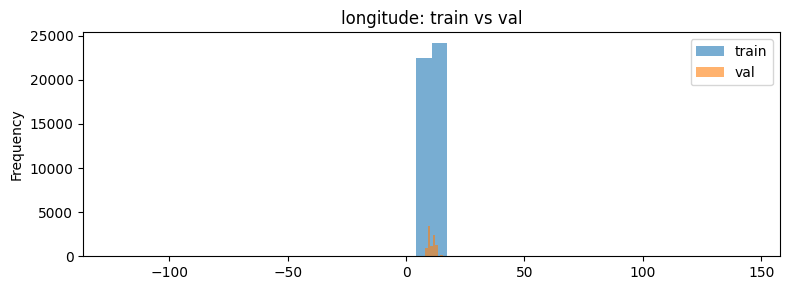

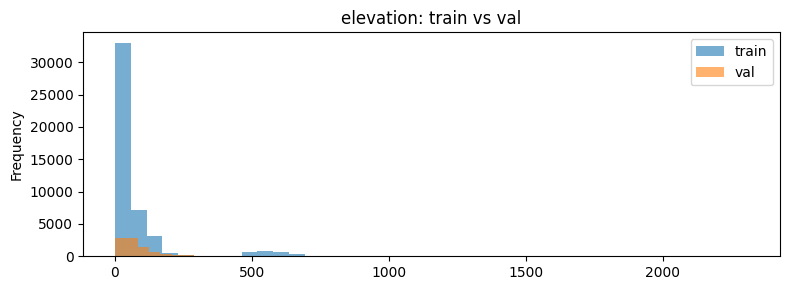

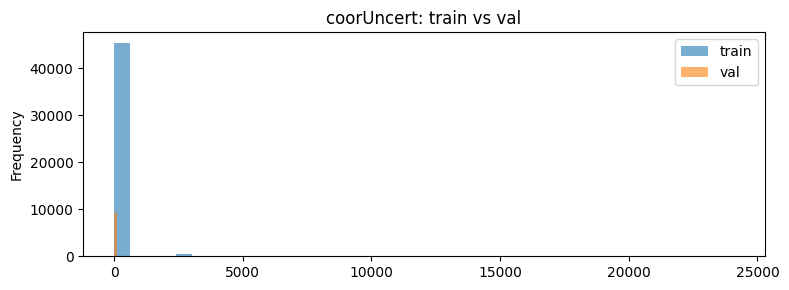

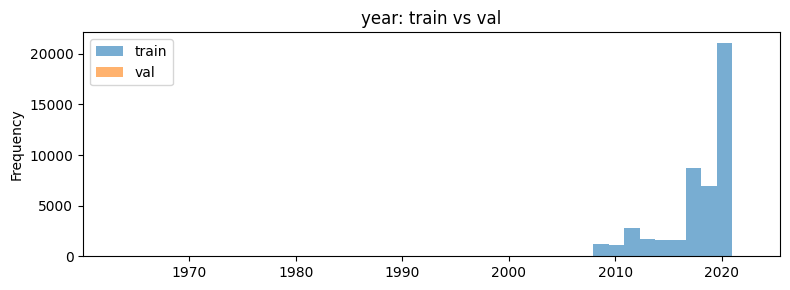

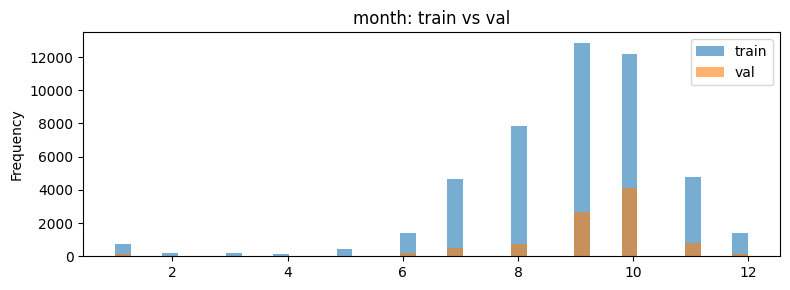

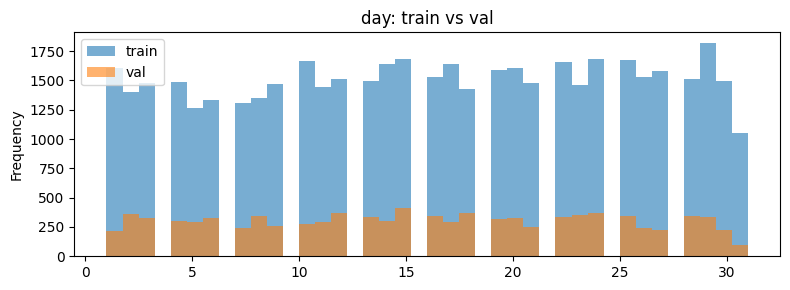

In [39]:
for c in NUM_COLS:
    plt.figure(figsize=(8,3))
    train_df[c].dropna().plot(kind="hist", bins=40, alpha=0.6, label="train")
    val_df[c].dropna().plot(kind="hist",   bins=40, alpha=0.6, label="val")
    plt.title(f"{c}: train vs val"); plt.legend(); plt.tight_layout(); plt.show()


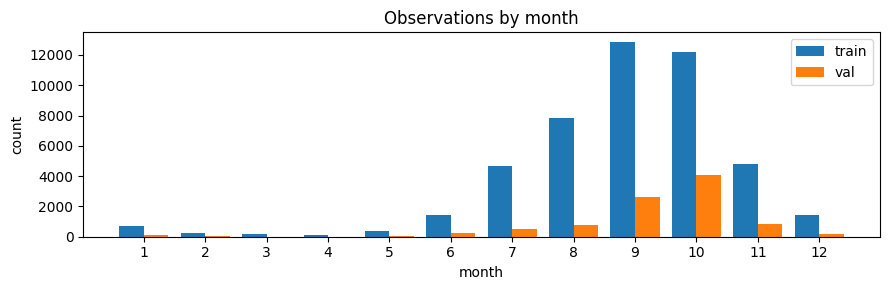

In [40]:
# time based patterns
m_tr = train_df["month"].fillna(0).astype(int)
m_va = val_df["month"].fillna(0).astype(int)
monthly_tr = m_tr[m_tr.between(1,12)].value_counts().sort_index()
monthly_va = m_va[m_va.between(1,12)].value_counts().sort_index()

x = np.arange(1,13)
plt.figure(figsize=(9,3))
plt.bar(x-0.2, [monthly_tr.get(i,0) for i in x], width=0.4, label="train")
plt.bar(x+0.2, [monthly_va.get(i,0) for i in x], width=0.4, label="val")
plt.xticks(x); plt.xlabel("month"); plt.ylabel("count"); plt.title("Observations by month"); plt.legend()
plt.tight_layout(); plt.show()


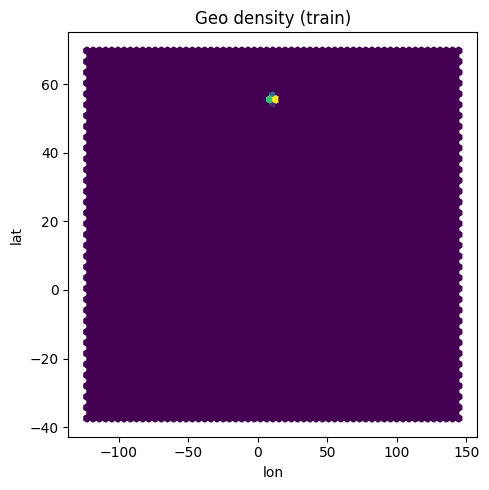

In [41]:
# Spatial Density when latitude or longitude present
if {"latitude","longitude"}.issubset(train_df.columns):
    plt.figure(figsize=(5,5))
    plt.hexbin(train_df["longitude"], train_df["latitude"], gridsize=60)
    plt.title("Geo density (train)"); plt.xlabel("lon"); plt.ylabel("lat"); plt.tight_layout(); plt.show()


/var/folders/_b/p210wqls6zd1qw_5y0_7w5_m0000gn/T/ipykernel_42481/3115219827.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.ylabel("MI"); plt.tight_layout(); plt.show()


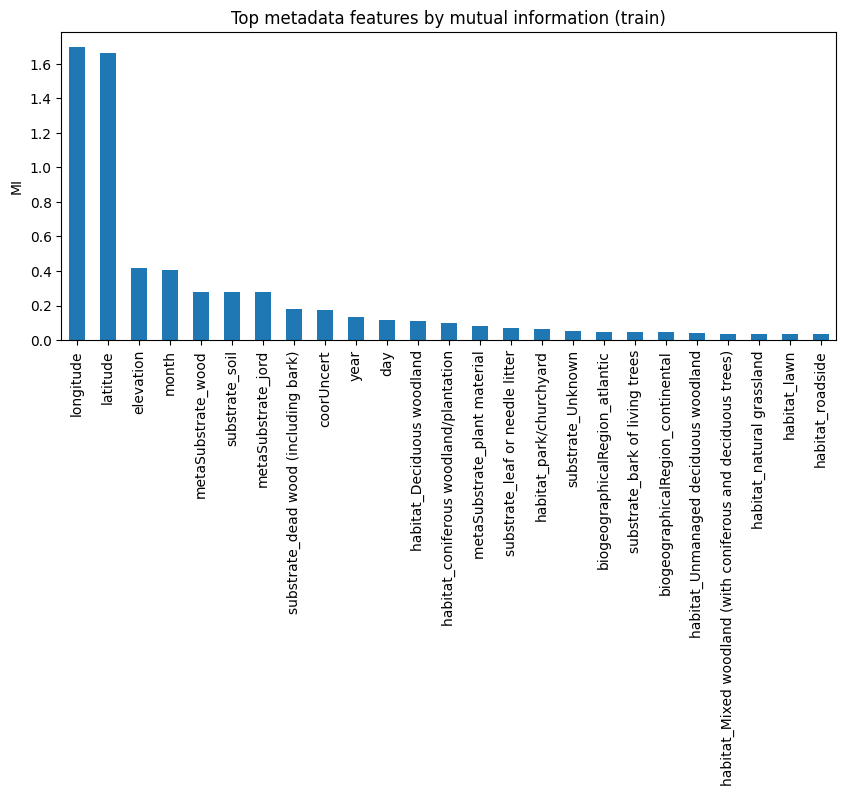

In [42]:
from sklearn.feature_selection import mutual_info_classif

# simple one-hot for cats
X_num = train_df[NUM_COLS].copy()
X_cat = pd.get_dummies(train_df[CAT_COLS].fillna("Unknown"), dummy_na=False)
X = pd.concat([X_num, X_cat], axis=1).fillna(0)
y = train_df[LABEL].astype("category").cat.codes

mi = mutual_info_classif(X, y, discrete_features=[False]*len(NUM_COLS)+[True]*X_cat.shape[1], random_state=0)
mi_s = pd.Series(mi, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,4))
mi_s.head(25).plot(kind="bar")
plt.title("Top metadata features by mutual information (train)")
plt.ylabel("MI"); plt.tight_layout(); plt.show()


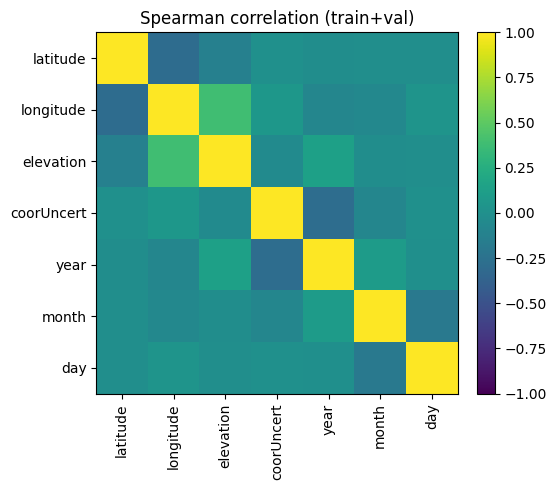

In [43]:
# Correlation heatmap (numeric only)
use = [c for c in NUM_COLS if train_df[c].notna().sum()>0]
corr = pd.concat([train_df[use], val_df[use]], axis=0).corr(method="spearman")

plt.figure(figsize=(6,5))
im = plt.imshow(corr.values, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(use)), use, rotation=90); plt.yticks(range(len(use)), use)
plt.title("Spearman correlation (train+val)"); plt.tight_layout(); plt.show()


In [49]:
# species concentration within top habitats
TOPH = 4
top_habs = train_df["habitat"].value_counts().head(TOPH).index
tab = (train_df[train_df["habitat"].isin(top_habs)]
       .groupby(["habitat", LABEL])["filename"].count()
       .groupby(level=0).apply(lambda s: (s/s.sum()*100).nlargest(5)))
print(tab.head(20))


habitat                                               habitat                                               species            
Deciduous woodland                                    Deciduous woodland                                    Clitocybe nebularis    4.372380
                                                                                                            Mycena galericulata    3.277146
                                                                                                            Russula adusta         3.251476
                                                                                                            Mycena crocata         3.114572
                                                                                                            Mycena rosea           3.114572
Mixed woodland (with coniferous and deciduous trees)  Mixed woodland (with coniferous and deciduous trees)  Mycena galericulata    4.923259
                                